In [1]:
import yaml
import torch
import pytorch_lightning as pl
from tqdm.auto import tqdm
import torch.nn as nn
import numpy as np 

/om4/group/mcdermott/user/imgriff/conda_envs_files/torch_11_cuda_11/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys 
sys.path.append('../')
from src.attn_tracking_lightning import AttentionalTrackingModule
from corpus.jsinV3AttnTrackingValidation import jsinV3_attn_tracking_validation
import src.audio_transforms as at


In [84]:
pl.seed_everything(1) 

Global seed set to 1


1

In [85]:
path = '../config/attentional_cue/attn_cue_lr_1e-4_bs_64.yaml'
config = yaml.load(open(path, 'r'), Loader=yaml.FullLoader)

In [86]:
config['data']['audio']['rep_kwargs']['rep_on_gpu'] = False

In [87]:

audio_config = config['data']['audio']

audio_transforms = at.AudioCompose([
            at.AudioToTensor(),
            at.CombineWithRandomDBSNR(low_snr=0, high_snr=0), # set to 0 so foreground/background at same level 
            at.RMSNormalizeForegroundAndBackground(rms_level=0.1),
            at.UnsqueezeAudio(dim=0),
            at.AudioToAudioRepresentation(**audio_config),
])


In [88]:

config['layernorm_first'] = False

model = AttentionalTrackingModule(config)

dataset = jsinV3_attn_tracking_validation(**config['data']['corpus'],
                                          train=False,
                                          transform=audio_transforms,
                                          demo=False)

dataloader = torch.utils.data.DataLoader(
            dataset,
            batch_size=1,
            num_workers=10
        )


In [89]:
ckpt_path = '../attn_cue_models/attn_cue_jsin_pilot_no_pretrain_pos_slope_bs_64_lr_1e-4/checkpoints/epoch=1-step=145791.ckpt'

ckpt = torch.load(ckpt_path, map_location=torch.device('cpu'))

model.load_state_dict(ckpt['state_dict'])


<All keys matched successfully>

In [90]:

# Set hook to get activations 
class SigmoidLayer(nn.Module):
    def __init__(self, bias, threshold, slope):
        super(SigmoidLayer, self).__init__()
        self.bias = bias
        self.threshold = threshold
        self.slope = slope
    
    def forward(self, x):
        return self.bias + (1 - self.bias) *  torch.sigmoid((x - self.threshold) * self.slope)
    

activations = {}


def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook



In [91]:
n_activations = 100
# set hooks for time_average layers & make SigmoidLayers

sigmoid_layers = nn.Sequential()

attn_time_average_outputs = {}
attn_output_dict = {}
cue_act_dict = {}

# Get attention parameters 
attn_modules = {name:module for name, module in model.model.named_children() if 'attn' in name}
cnn_channels = dict(zip(attn_modules.keys(), [1, 32, 64, 256, 512, 512, 512, 512]))



for name, module in attn_modules.items():

    module.time_average.register_forward_hook(get_activation(f"{name}_attn_in"))
    module.register_forward_hook(get_activation(f"{name}_attn_out"))

    sigmoid_layers.add_module(name, SigmoidLayer(module.bias, module.threshold, module.slope))
    
    out_size = torch.mul(*module.time_average.output_size) * cnn_channels[name]
    
    cue_act_dict[name] = torch.empty((n_activations, out_size), device=model.device)
    attn_time_average_outputs[name] = torch.empty((n_activations, out_size), device=model.device)
#     attn_output_dict[name] = []
    
# conv_modules = {name:module for name, module in model.model.named_children() if 'conv' in name}
# cnn_outputs = {}

# for name, module in conv_modules.items():
#     module.register_forward_hook(get_activation(name))
#     cnn_outputs[name] = []



In [92]:
device = model.device

In [93]:
device

device(type='cpu')

In [94]:
model = model.eval().cuda()

sigmoid_layers = sigmoid_layers.cuda()

input_mixtures = np.empty((100, 40 * 16000))

with torch.no_grad():
    for ix, batch in tqdm(enumerate(dataloader),  total = n_activations):
        signal, fg_cue, bg_cue, fg_target, bg_target = batch
        input_mixtures[ix] = signal.numpy().reshape(1,-1)
        model(fg_cue.cuda(), signal.cuda())
#         print(activations)
        for layer in attn_time_average_outputs.keys():
            attn_input = activations[f"{layer}_attn_in"]
            cue_act_dict[layer][ix,:] = attn_input.view(1,-1)
            attn_time_average_outputs[layer][ix,:] = sigmoid_layers.get_submodule(layer).forward(attn_input).view(1,-1)
#             attn_output_dict[layer].append(activations[f"{layer}_attn_out"].view(1,-1))
            
            
#         for layer in cnn_outputs.keys():
#              cnn_outputs[layer].append(activations[layer].view(1,-1))
        
        if ix == n_activations-1:
            break 

 99%|█████████▉| 99/100 [00:08<00:00, 12.24it/s]


In [95]:
# Reformat for plotting 
# Models trained using 16 bit precission 

cue_act_dict = {layer:acts.cpu().numpy().ravel().astype('float16') for layer,acts in cue_act_dict.items()}
attn_time_average_outputs = {layer:acts.cpu().numpy().ravel().astype('float16') 
                             for layer,acts in attn_time_average_outputs.items()}

# cnn_outputs = {layer:torch.cat(acts).cpu().numpy().ravel().astype('float32') for layer,acts in cnn_outputs.items()}
# attn_output_dict = {layer:torch.cat(acts).cpu().numpy().ravel().astype('float32')
#                     for layer,acts in attn_output_dict.items()}


### Plost histograms of activations

In [96]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter


In [97]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def attn_gain(x, bias, slope, threshold):
    return bias + (1-bias) * sigmoid((x - threshold) * slope)
    

In [98]:
# len(attn_output_dict), len(cnn_outputs)

In [99]:
#  sns.histplot(input_mixtures.flatten().astype('float32'), stat='percent', log_scale=(False, True),
#                  bins=n_hist_bins, #binrange=(layer_activations.min(), layer_activations.max()),
#                  color='blue', alpha=.5, edgecolor='0.1')

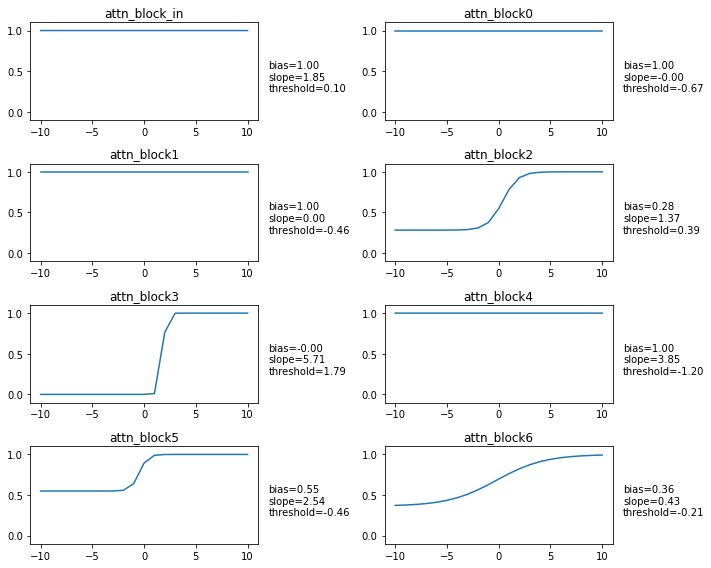

In [103]:
fig, axs = plt.subplots(4,2, figsize=(10,8))


axs = axs.ravel()
# layer_names = ['cochleagram'] + layer_names

x = np.arange(-10,11)

for i, name in enumerate(attn_modules.keys()):
    bias =  attn_modules[name].bias.item()
    slope =  attn_modules[name].slope.item()
    threshold =  attn_modules[name].threshold.item()
    gain = attn_gain(x ,
                bias,
                 slope,
                 threshold)
    axs[i].plot(x, gain)
    axs[i].text(12, 0.25, f"bias={bias:.2f}\nslope={slope:.2f}\nthreshold={threshold:.2f}")
    axs[i].set_title(name)
    axs[i].set_ylim(-0.1,1.1)

#     axs[i].set_xlim(-1,1)

    
    
plt.tight_layout()

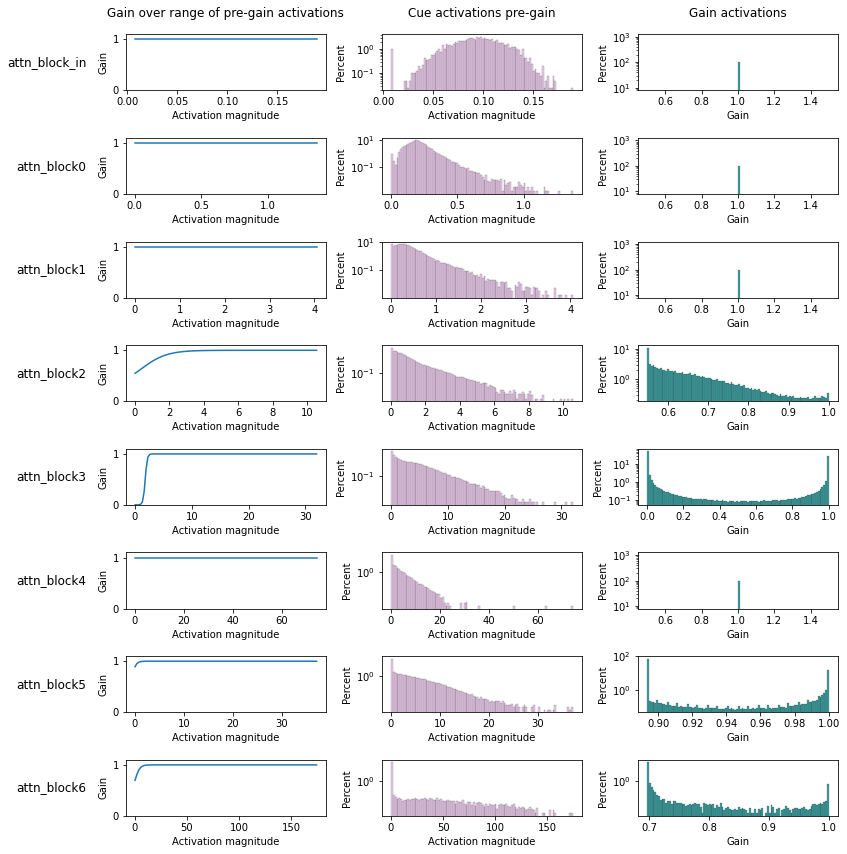

In [108]:

# Look at inputs to gain functions 
fig, axs = plt.subplots(8,3, figsize=(12,12))
# axs = axs.ravel()

n_hist_bins = 100
pad = 8


for ix, name in enumerate(attn_modules.keys()):
    layer_activations = cue_act_dict[name] # input to gain
    layer_outputs = attn_time_average_outputs[name] # output from gain
    
    
    
    x_for_sig = np.linspace(layer_activations.min(), layer_activations.max(), n_hist_bins)
    gain = attn_gain(x_for_sig,
                     attn_modules[name].bias.item(),
                     attn_modules[name].slope.item(),
                     attn_modules[name].threshold.item())

    axs[ix,0].plot(x_for_sig, gain)

    # plot hist of activations
    sns.histplot(layer_activations, stat='percent', log_scale=(False, True),
                 bins=n_hist_bins, #binrange=(layer_activations.min(), layer_activations.max()),
                 ax=axs[ix,1], color='plum', alpha=.5, edgecolor='0.1')
    
    # plot functional range of sigmoid
    # get params 
    sns.histplot(layer_outputs, stat='percent',  log_scale=(False, True),
                 bins=n_hist_bins, #binrange=(layer_outputs.min(), layer_outputs.max()),
                 ax=axs[ix,2], color='teal', edgecolor='0.1')


    
    axs[ix,0].annotate(name, xy=(0, 0.5), xytext=(-axs[ix,0].yaxis.labelpad - pad, 0),
                xycoords=axs[ix,0].yaxis.label, textcoords='offset points',
                size='large', ha='right', va='center')
    
    axs[ix,0].set_ylabel("Gain")
    
    axs[ix,0].set_xlabel("Activation magnitude")
    axs[ix,1].set_xlabel("Activation magnitude")
    axs[ix,2].set_xlabel("Gain")
    
    axs[ix,0].ticklabel_format(useOffset=False)
#     axs[ix,1].ticklabel_format(useOffset=False)
#     axs[ix,2].ticklabel_format(useOffset=False)

    
axs[0,0].set_title("Gain over range of pre-gain activations", y=1.2)
axs[0,1].set_title("Cue activations pre-gain", y=1.2)
axs[0,2].set_title("Gain activations", y=1.2)


for ax in axs[:,0].ravel():
    ax.set_ylim(0,1.1)
    
# # for ax in axs[:,0].ravel():
# axs[0,2].xaxis.set_major_formatter(FormatStrFormatter('%.6f'))
# axs[5,2].xaxis.set_major_formatter(FormatStrFormatter('%.7f'))


plt.tight_layout()

In [58]:

# # Look at inputs to gain functions 
# fig, axs = plt.subplots(8,2, figsize=(12,12))
# # axs = axs.ravel()

# n_hist_bins = 50
# pad = 8

# attn_module_names = list(attn_output_dict.keys())
# cnn_module_names = list(cnn_outputs.keys())


# for ix in range(len(attn_module_names)):
#     if ix == 0:
#         pre_name = 'cochleagram'
#         pre_attention_activations = input_mixtures.flatten().astype('float32')
#     else:
#         pre_name = cnn_module_names[ix-1]
#         pre_attention_activations = cnn_outputs[pre_name]
    
#     attn_name = attn_module_names[ix]
#     attn_activations = attn_output_dict[attn_name] 
    
#         # plot hist of activations
#     sns.histplot(pre_attention_activations, stat='percent', log_scale=(False, True),
#                  bins=n_hist_bins, #binrange=(layer_activations.min(), layer_activations.max()),
#                  ax=axs[ix,0], color='blue', alpha=.5, edgecolor='0.1')
    
#     # plot functional range of sigmoid
#     # get params 
#     sns.histplot(attn_activations, stat='percent',  log_scale=(False, True),
#                  bins=n_hist_bins, #binrange=(layer_outputs.min(), layer_outputs.max()),
#                  ax=axs[ix,1], color='red', edgecolor='0.1')
    
    
#     axs[ix,0].set_xlabel("Activation magnitude")
#     axs[ix,1].set_xlabel("Activation magnitude")
    
#     axs[ix,0].set_title(f"{pre_name} activations")
#     axs[ix,1].set_title(f"{attn_name} activations")



# plt.tight_layout()

1.0